In [ ]:
import pandas as pd

df = pd.read_csv("/content/Tweets.csv")

# Keep required columns
df = df[['text', 'sentiment']]

# Drop null values
df = df.dropna()

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['sentiment'] = le.fit_transform(df['sentiment'])

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df['text'])

sequences = tokenizer.texts_to_sequences(df['text'])

In [ ]:
sequence_lengths = [20, 50, 100, 200]

In [ ]:
from sklearn.model_selection import train_test_split

X = sequences
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

def build_rnn(max_len):
    model = Sequential()
    model.add(Embedding(input_dim=10000, output_dim=128, input_length=max_len))
    model.add(SimpleRNN(64))
    model.add(Dense(3, activation='softmax'))
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [ ]:
from tensorflow.keras.layers import LSTM

def build_lstm(max_len):
    model = Sequential()
    model.add(Embedding(input_dim=10000, output_dim=128, input_length=max_len))
    model.add(LSTM(64))
    model.add(Dense(3, activation='softmax'))
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [ ]:
rnn_acc = []
lstm_acc = []

for max_len in sequence_lengths:
    print(f"Running for sequence length: {max_len}")

    X_pad = pad_sequences(sequences, maxlen=max_len)

    X_train, X_test, y_train, y_test = train_test_split(X_pad, y, test_size=0.2)

    # RNN
    rnn = build_rnn(max_len)
    rnn.fit(X_train, y_train, epochs=1, batch_size=64, verbose=1)
    _, acc_rnn = rnn.evaluate(X_test, y_test, verbose=0)
    rnn_acc.append(acc_rnn)

    # LSTM
    lstm = build_lstm(max_len)
    lstm.fit(X_train, y_train, epochs=1, batch_size=64, verbose=1)
    _, acc_lstm = lstm.evaluate(X_test, y_test, verbose=0)
    lstm_acc.append(acc_lstm)

Running for sequence length: 20
344/344 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.5746 - loss: 0.8892
344/344 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.6103 - loss: 0.8345
Running for sequence length: 50
344/344 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.5615 - loss: 0.9032
344/344 ━━━━━━━━━━━━━━━━━━━━ 27s 70ms/step - accuracy: 0.6173 - loss: 0.8269
Running for sequence length: 100
344/344 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.5604 - loss: 0.9038
344/344 ━━━━━━━━━━━━━━━━━━━━ 49s 136ms/step - accuracy: 0.6184 - loss: 0.8260
Running for sequence length: 200
344/344 ━━━━━━━━━━━━━━━━━━━━ 33s 89ms/step - accuracy: 0.5433 - loss: 0.9305
344/344 ━━━━━━━━━━━━━━━━━━━━ 87s 247ms/step - accuracy: 0.5883 - loss: 0.8697


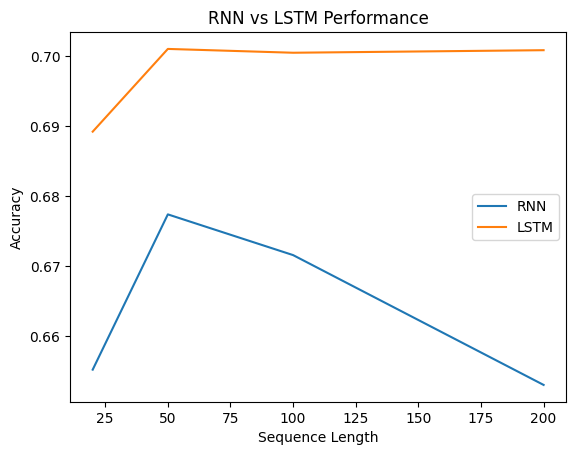

In [ ]:
import matplotlib.pyplot as plt

plt.plot(sequence_lengths, rnn_acc, label='RNN')
plt.plot(sequence_lengths, lstm_acc, label='LSTM')

plt.xlabel("Sequence Length")
plt.ylabel("Accuracy")
plt.title("RNN vs LSTM Performance")
plt.legend()
plt.show()